In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load features and target from parquet files
features_path = "../data/user_activity/featured/features_balanced.parquet"
target_path = "../data/user_activity/featured/target_balanced.parquet"

X = pd.read_parquet(features_path)
y_loaded = pd.read_parquet(target_path)

print(X.columns)

Index(['blocks_initiated_active_days', 'blocks_initiated_last_day',
       'follows_made_active_days', 'follows_made_last_day',
       'last_active_overall', 'likes_made_last_day',
       'follows_received_active_days', 'likes_made_active_days',
       'posts_last_active_day', 'blocks_received_active_days',
       'posts_active_days', 'blocks_ratio_initiated_received',
       'likes_made_total', 'likes_received_active_days', 'follows_made_total',
       'posts_first_active_day', 'blocks_initiated_per_active_day',
       'blocks_initiated_total', 'blocks_net_balance', 'posts_avg',
       'posts_total', 'follows_received_total'],
      dtype='object')


## Multi-Output Multi-Horizon Prediction Strategy

We'll train **multi-output models** that predict block activity classes for weeks 2, 3, and 4 **simultaneously** from week 1 features:
- 0 blocks -> class 0 (Inactive)
- 1–3 blocks -> class 1 (Low activity)
- 4+ blocks -> class 2 (High activity)

**Key approach:**
- Single model takes week 1 features as input
- Outputs 3 predictions: [week2_class, week3_class, week4_class]
- Uses `MultiOutputClassifier` wrapper for compatibility with standard sklearn models

**Goals:**
1. Predict user behavior across multiple future time horizons in one forward pass
2. Capture temporal dependencies between consecutive weeks
3. Compare single multi-output model vs separate models per week
4. Visualize confusion matrices and performance metrics across all weeks

This helps us understand behavioral consistency and temporal prediction patterns.

In [3]:
# Extract class targets for all three weeks
# The target file now contains both count and class columns
print("Available target columns:")
print(y_loaded.columns.tolist())

# Use the pre-computed class columns from feature engineering
y_week2 = y_loaded['blocks_week2_class'].astype(int)
y_week3 = y_loaded['blocks_week3_class'].astype(int)
y_week4 = y_loaded['blocks_week4_class'].astype(int)

# Create multi-output target matrix (each row has 3 values: week2, week3, week4)
y_multi = pd.DataFrame({
    'week2': y_week2,
    'week3': y_week3,
    'week4': y_week4
})

print('\nMulti-output target shape:', y_multi.shape)
print('Sample multi-output targets (first 10 users):')
print(y_multi.head(10))

# Display class distributions for all weeks
print('\n' + '='*70)
print('CLASS DISTRIBUTIONS ACROSS WEEKS')
print('='*70)

for week_num, y_target in [('Week 2', y_week2), ('Week 3', y_week3), ('Week 4', y_week4)]:
    print(f'\n{week_num} class distribution:')
    dist = y_target.value_counts().sort_index()
    print(dist)
    print(f'Percentages: {(y_target.value_counts(normalize=True).sort_index() * 100).round(2).to_dict()}')

# Sample check
print('\n' + '='*70)
print('Sample target values (first 10 users):')
sample_df = pd.DataFrame({
    'did_id': y_loaded['did_id'].head(10).values,
    'week2_class': y_week2.head(10).values,
    'week3_class': y_week3.head(10).values,
    'week4_class': y_week4.head(10).values
})
print(sample_df.to_string(index=False))

Available target columns:
['did_id', 'blocks_week2_initiated', 'blocks_week2_class', 'blocks_week3_initiated', 'blocks_week3_class', 'blocks_week4_initiated', 'blocks_week4_class']

Multi-output target shape: (76074, 3)
Sample multi-output targets (first 10 users):
   week2  week3  week4
0      1      1      1
1      0      0      0
2      0      0      0
3      0      2      1
4      1      2      2
5      0      0      0
6      0      0      1
7      1      2      2
8      1      2      2
9      2      2      2

CLASS DISTRIBUTIONS ACROSS WEEKS

Week 2 class distribution:
blocks_week2_class
0    25358
1    25358
2    25358
Name: count, dtype: int64
Percentages: {0: 33.33, 1: 33.33, 2: 33.33}

Week 3 class distribution:
blocks_week3_class
0    37167
1    18592
2    20315
Name: count, dtype: int64
Percentages: {0: 48.86, 1: 24.44, 2: 26.7}

Week 4 class distribution:
blocks_week4_class
0    42050
1    17342
2    16682
Name: count, dtype: int64
Percentages: {0: 55.28, 1: 22.8, 2: 21.93}

In [4]:
# Prepare data for multi-output models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Split data once for all models
# We stratify by week2 class (could also use a combination, but week2 is a good proxy)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_multi, test_size=0.5, random_state=42, stratify=y_multi['week2']
)

print(f'Train/Test split: {X_train.shape} / {X_test.shape}')
print(f'Multi-output targets: {y_train.shape} / {y_test.shape}')

# Scale features (will be used for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check class distributions in train set
print('\nTrain set class distributions:')
for week_col in ['week2', 'week3', 'week4']:
    print(f'{week_col}: {y_train[week_col].value_counts(normalize=True).sort_index().to_dict()}')

print('\n✓ Data prepared for multi-output models')

Train/Test split: (38037, 22) / (38037, 22)
Multi-output targets: (38037, 3) / (38037, 3)

Train set class distributions:
week2: {0: 0.3333333333333333, 1: 0.3333333333333333, 2: 0.3333333333333333}
week3: {0: 0.48776191602912955, 1: 0.24699634566343298, 2: 0.26524173830743747}
week4: {0: 0.5532244919420565, 1: 0.2263848358177564, 2: 0.22039067224018719}

✓ Data prepared for multi-output models


### Train Multi-Output Models

We'll train three types of multi-output models that predict all three weeks simultaneously.

In [5]:
# Train Multi-Output Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

print('='*80)
print('TRAINING MULTI-OUTPUT LOGISTIC REGRESSION')
print('='*80)

# Create base classifier
base_lr = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs',
    max_iter=1000, 
    class_weight='balanced',
    random_state=42
)

# Wrap in MultiOutputClassifier
multi_lr = MultiOutputClassifier(base_lr, n_jobs=-1)

# Train on scaled data
print('\nTraining model (predicts week2, week3, week4 simultaneously)...')
multi_lr.fit(X_train_scaled, y_train)

# Predict all three weeks at once
y_pred_multi = multi_lr.predict(X_test_scaled)
print(f'Predictions shape: {y_pred_multi.shape}')

# Convert predictions to DataFrame for easier handling
y_pred_df = pd.DataFrame(y_pred_multi, columns=['week2', 'week3', 'week4'])

# Compute metrics for each week
lr_results = {}
for idx, week_name in enumerate(['Week2', 'Week3', 'Week4']):
    week_col = f'week{idx+2}'
    
    y_true = y_test[week_col].values
    y_pred = y_pred_df[week_col].values
    
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)
    class_report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    
    lr_results[week_name] = {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'confusion_matrix': cm,
        'classification_report': class_report,
        'y_true': y_true,
        'y_pred': y_pred
    }
    
    print(f'\n{week_name}:')
    print(f'  Accuracy: {acc:.4f}')
    print(f'  Macro F1: {f1_macro:.4f}')
    print(f'  Weighted F1: {f1_weighted:.4f}')

print('\n✓ Multi-Output Logistic Regression trained')

TRAINING MULTI-OUTPUT LOGISTIC REGRESSION

Training model (predicts week2, week3, week4 simultaneously)...
Predictions shape: (38037, 3)

Week2:
  Accuracy: 0.3332
  Macro F1: 0.3328
  Weighted F1: 0.3328

Week3:
  Accuracy: 0.3158
  Macro F1: 0.3138
  Weighted F1: 0.3173

Week4:
  Accuracy: 0.3049
  Macro F1: 0.3013
  Weighted F1: 0.3136

✓ Multi-Output Logistic Regression trained


### Train Multi-Output Random Forest

In [6]:
# Train Multi-Output Random Forest
from sklearn.ensemble import RandomForestClassifier

print('='*80)
print('TRAINING MULTI-OUTPUT RANDOM FOREST')
print('='*80)

# Create base classifier with REDUCED parameters to prevent memory crashes
# Key changes:
# 1. Reduced n_estimators from 200 to 100 (fewer trees = less memory)
# 2. Added max_depth to limit tree size
# 3. Added min_samples_split to prevent overfitting on small splits
# 4. Removed n_jobs from base classifier (parallelism handled by MultiOutputClassifier)
base_rf = RandomForestClassifier(
    n_estimators=40,          # Reduced from 200 (saves 50% memory)
    max_depth=15,              # Limits tree depth (prevents excessive memory)
    min_samples_split=5,       # Prevents tiny splits (speeds up training)
    min_samples_leaf=2,        # Minimum samples per leaf
    max_features='sqrt',       # Use sqrt of features (default, but explicit)
    random_state=42,
    class_weight='balanced',
    n_jobs=-1                   # Single-threaded at base level
)

# Wrap in MultiOutputClassifier - parallelism happens HERE
# This trains 3 separate forests (one per week) in parallel
multi_rf = MultiOutputClassifier(base_rf, n_jobs=-1)

# Train on raw data (tree models don't need scaling)
print('\nTraining model (predicts week2, week3, week4 simultaneously)...')
print('Note: Using optimized parameters to reduce memory usage')
print(f'  - 100 trees per output (down from 200)')
print(f'  - Max depth: 20 levels')
print(f'  - Parallelism: 3 forests trained in parallel (one per week)')

multi_rf.fit(X_train, y_train)

# Predict all three weeks at once
y_pred_multi = multi_rf.predict(X_test)
print(f'Predictions shape: {y_pred_multi.shape}')

# Convert predictions to DataFrame
y_pred_df = pd.DataFrame(y_pred_multi, columns=['week2', 'week3', 'week4'])

# Compute metrics for each week
rf_results = {}
for idx, week_name in enumerate(['Week2', 'Week3', 'Week4']):
    week_col = f'week{idx+2}'
    
    y_true = y_test[week_col].values
    y_pred = y_pred_df[week_col].values
    
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)
    class_report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    
    rf_results[week_name] = {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'confusion_matrix': cm,
        'classification_report': class_report,
        'y_true': y_true,
        'y_pred': y_pred
    }
    
    print(f'\n{week_name}:')
    print(f'  Accuracy: {acc:.4f}')
    print(f'  Macro F1: {f1_macro:.4f}')
    print(f'  Weighted F1: {f1_weighted:.4f}')

print('\n✓ Multi-Output Random Forest trained (optimized configuration)')

TRAINING MULTI-OUTPUT RANDOM FOREST

Training model (predicts week2, week3, week4 simultaneously)...
Note: Using optimized parameters to reduce memory usage
  - 100 trees per output (down from 200)
  - Max depth: 20 levels
  - Parallelism: 3 forests trained in parallel (one per week)
Predictions shape: (38037, 3)

Week2:
  Accuracy: 0.3296
  Macro F1: 0.3293
  Weighted F1: 0.3293

Week3:
  Accuracy: 0.3668
  Macro F1: 0.3323
  Weighted F1: 0.3681

Week4:
  Accuracy: 0.4134
  Macro F1: 0.3304
  Weighted F1: 0.4076

✓ Multi-Output Random Forest trained (optimized configuration)


### Train Multi-Output Gradient Boosting

In [7]:
# Train Multi-Output Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

print('='*80)
print('TRAINING MULTI-OUTPUT GRADIENT BOOSTING')
print('='*80)

# Create base classifier
base_gb = GradientBoostingClassifier(
    random_state=42,
    n_estimators=70
)

# Wrap in MultiOutputClassifier
multi_gb = MultiOutputClassifier(base_gb, n_jobs=-1)

# Train on raw data
print('\nTraining model (predicts week2, week3, week4 simultaneously)...')
multi_gb.fit(X_train, y_train)

# Predict all three weeks at once
y_pred_multi = multi_gb.predict(X_test)
print(f'Predictions shape: {y_pred_multi.shape}')

# Convert predictions to DataFrame
y_pred_df = pd.DataFrame(y_pred_multi, columns=['week2', 'week3', 'week4'])

# Compute metrics for each week
gb_results = {}
for idx, week_name in enumerate(['Week2', 'Week3', 'Week4']):
    week_col = f'week{idx+2}'
    
    y_true = y_test[week_col].values
    y_pred = y_pred_df[week_col].values
    
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)
    class_report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    
    gb_results[week_name] = {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'confusion_matrix': cm,
        'classification_report': class_report,
        'y_true': y_true,
        'y_pred': y_pred
    }
    
    print(f'\n{week_name}:')
    print(f'  Accuracy: {acc:.4f}')
    print(f'  Macro F1: {f1_macro:.4f}')
    print(f'  Weighted F1: {f1_weighted:.4f}')

print('\n✓ Multi-Output Gradient Boosting trained')

# Consolidate all results
all_results = {
    'LogisticRegression': lr_results,
    'RandomForest': rf_results,
    'GradientBoosting': gb_results
}

print('\n' + '='*80)
print('ALL MULTI-OUTPUT MODEL TRAINING COMPLETE')
print('='*80)

TRAINING MULTI-OUTPUT GRADIENT BOOSTING

Training model (predicts week2, week3, week4 simultaneously)...
Predictions shape: (38037, 3)

Week2:
  Accuracy: 0.3326
  Macro F1: 0.3324
  Weighted F1: 0.3324

Week3:
  Accuracy: 0.4886
  Macro F1: 0.2200
  Weighted F1: 0.3222

Week4:
  Accuracy: 0.5518
  Macro F1: 0.2376
  Weighted F1: 0.3932

✓ Multi-Output Gradient Boosting trained

ALL MULTI-OUTPUT MODEL TRAINING COMPLETE


MULTI-OUTPUT MODEL PERFORMANCE ACROSS WEEKS
             Model   Week  Accuracy  Macro F1  Weighted F1
LogisticRegression Week 2  0.333176  0.332770     0.332770
LogisticRegression Week 3  0.315798  0.313775     0.317327
LogisticRegression Week 4  0.304940  0.301307     0.313587
      RandomForest Week 2  0.329600  0.329332     0.329332
      RandomForest Week 3  0.366801  0.332339     0.368128
      RandomForest Week 4  0.413361  0.330421     0.407573
  GradientBoosting Week 2  0.332623  0.332377     0.332377
  GradientBoosting Week 3  0.488629  0.219998     0.322163
  GradientBoosting Week 4  0.551779  0.237626     0.393165


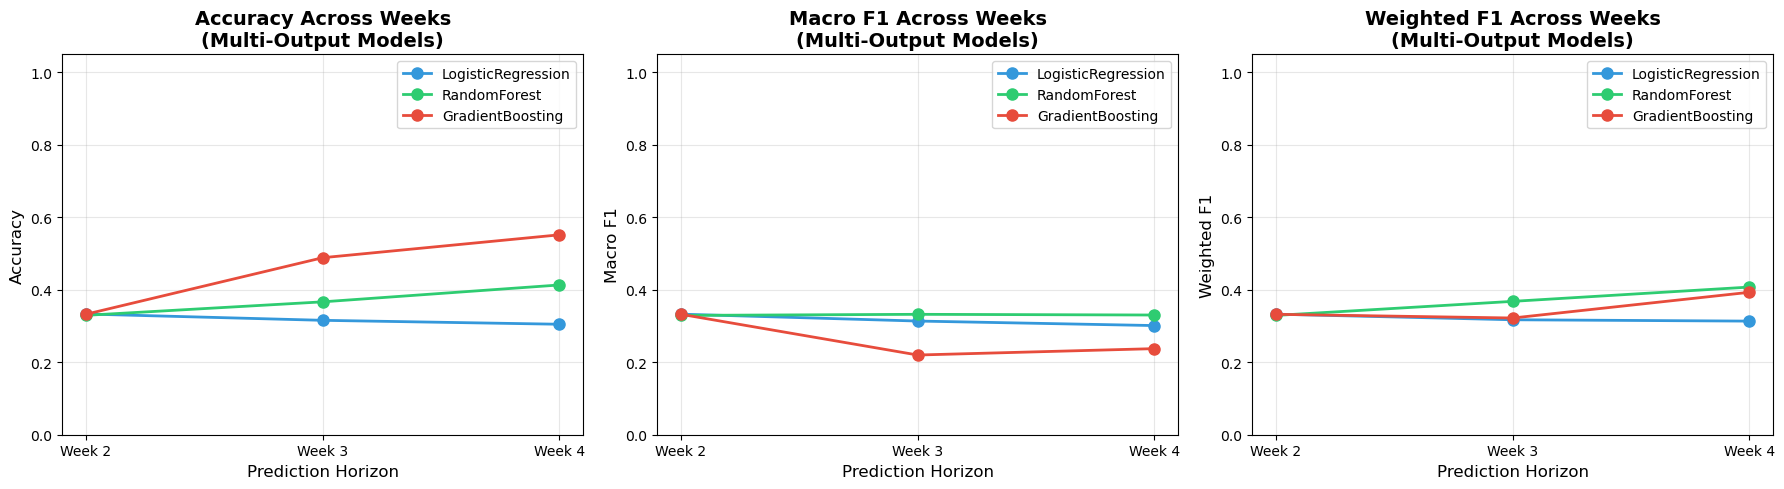


BEST MODEL PER WEEK (by Macro F1)
Week 2: LogisticRegression (Macro F1 = 0.3328)
Week 3: RandomForest (Macro F1 = 0.3323)
Week 4: RandomForest (Macro F1 = 0.3304)


In [8]:
# Comparative performance visualization across weeks
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create performance comparison table
performance_data = []
for model_name in ['LogisticRegression', 'RandomForest', 'GradientBoosting']:
    for week in ['Week2', 'Week3', 'Week4']:
        res = all_results[model_name][week]
        performance_data.append({
            'Model': model_name,
            'Week': week.replace('Week', 'Week '),
            'Accuracy': res['accuracy'],
            'Macro F1': res['f1_macro'],
            'Weighted F1': res['f1_weighted']
        })

perf_df = pd.DataFrame(performance_data)

print('='*80)
print('MULTI-OUTPUT MODEL PERFORMANCE ACROSS WEEKS')
print('='*80)
print(perf_df.to_string(index=False))

# 2. Visual comparison: line plots of metrics across weeks
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Accuracy', 'Macro F1', 'Weighted F1']
colors = {'LogisticRegression': '#3498db', 'RandomForest': '#2ecc71', 'GradientBoosting': '#e74c3c'}

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    for model_name in ['LogisticRegression', 'RandomForest', 'GradientBoosting']:
        model_data = perf_df[perf_df['Model'] == model_name]
        ax.plot(model_data['Week'], model_data[metric], 
                marker='o', linewidth=2, markersize=8, 
                label=model_name, color=colors[model_name])
    
    ax.set_title(f'{metric} Across Weeks\n(Multi-Output Models)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Prediction Horizon', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# 3. Best model per week
print('\n' + '='*80)
print('BEST MODEL PER WEEK (by Macro F1)')
print('='*80)
for week in ['Week2', 'Week3', 'Week4']:
    best_model = max(all_results.items(), key=lambda x: x[1][week]['f1_macro'])
    print(f"{week.replace('Week', 'Week ')}: {best_model[0]} (Macro F1 = {best_model[1][week]['f1_macro']:.4f})")

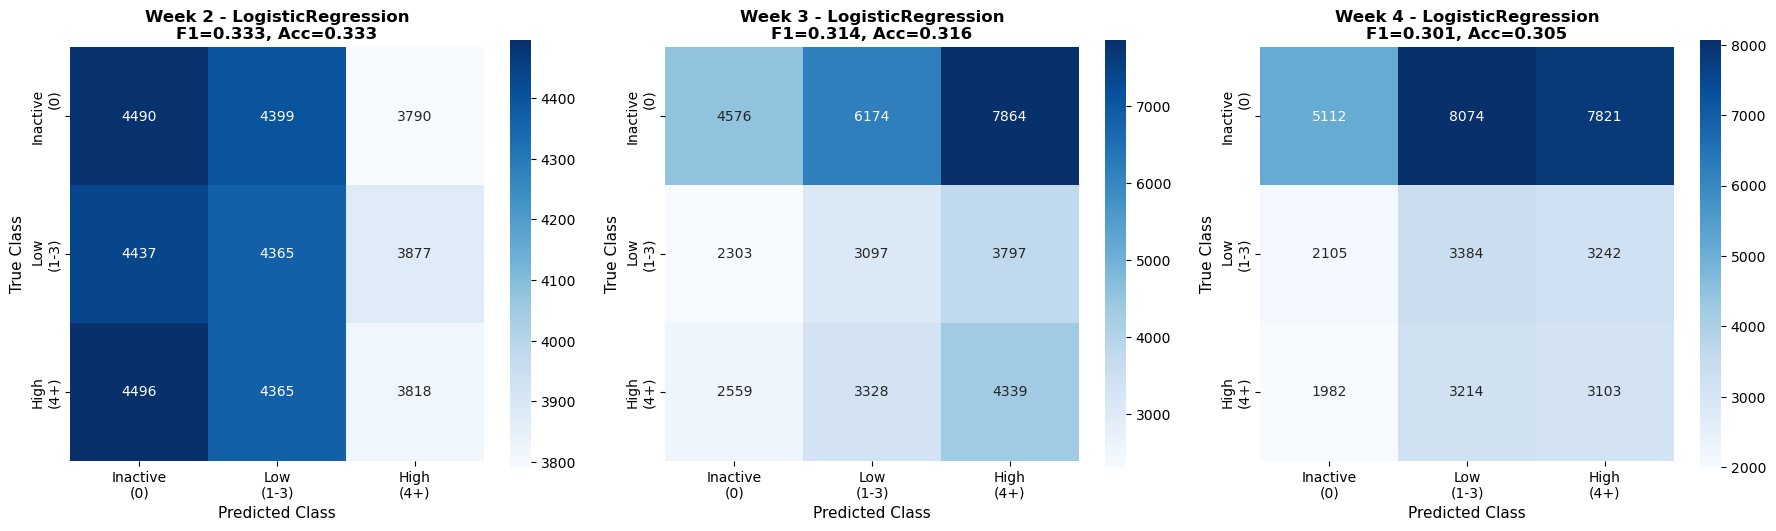

In [11]:
best_model_name = 'LogisticRegression'

# Plot confusion matrices for best model across weeks
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_labels = ['Inactive\n(0)', 'Low\n(1-3)', 'High\n(4+)']

for idx, week in enumerate(['Week2', 'Week3', 'Week4']):
    ax = axes[idx]
    cm = all_results[best_model_name][week]['confusion_matrix']
    
    # Normalize confusion matrix for better visualization
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                cbar=True, square=True)
    
    f1 = all_results[best_model_name][week]['f1_macro']
    acc = all_results[best_model_name][week]['accuracy']
    ax.set_title(f'{week.replace("Week", "Week ")} - {best_model_name}\nF1={f1:.3f}, Acc={acc:.3f}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Class', fontsize=11)
    ax.set_ylabel('True Class', fontsize=11)

plt.tight_layout()
plt.show()